# 📚 Классификация: от логистической регрессии до метрик ранжирования

---

## Раздел 0. Как работать с этим ноутбуком

**Этот ноутбук — рабочая тетрадь, а не учебник для чтения.**

### Что здесь есть:
- Все ключевые **формулы уже написаны** в markdown-ячейках.
- Часть кода **уже готова** — запускай и смотри результат.
- Часть кода нужно **дописать самому** — эти места явно помечены:

```python
# ========= TODO =========
# ваш код здесь
# ========================
```

### Что нужно делать:
1. Читать формулы и разбираться, что они означают.
2. **Переносить формулы в код** — аккуратно, строчка за строчкой.
3. Дописывать **1–3 строки** там, где стоит TODO.
4. **Смотреть на результаты** и отвечать на вопросы.

### Чего здесь нет:
- Нет ничего про "правильную архитектуру кода".
- Нет классов, нет сложных паттернов.
- Есть только **математика, реализованная через простые функции**.

> 💡 **Цель** — понять, как работает бинарная и многоклассовая классификация, зачем нужны разные функции потерь и метрики.

---

## 🗺️ План занятия

| # | Тема |
|---|------|
| 1 | Задача бинарной классификации и линейный score |
| 2 | Сигмоида |
| 3 | Функции потерь: MSE, Binary Cross-Entropy |
| 4 | Логистическая регрессия руками (без sklearn) |
| 5 | Порог классификации |
| 6 | ROC-кривая и ROC-AUC руками |
| 7 | ROC-AUC как вероятность правильной сортировки |
| 8 | Precision@k и Recall@k |
| 9 | Многоклассовая классификация: One-vs-All |
| 10 | Итоги |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Для генерации датасетов и финальной проверки
from sklearn.datasets import make_classification, make_blobs
from sklearn.metrics import roc_auc_score, roc_curve as sk_roc_curve

np.random.seed(42)

# Единый стиль графиков
plt.rcParams.update(
    {
        'figure.dpi': 110,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
    }
)

---
## Раздел 1. Задача бинарной классификации

### Постановка задачи

Дан набор объектов $x_i \in \mathbb{R}^d$ с метками $y_i \in \{0, 1\}$.  
**Задача:** научиться предсказывать метку по признакам объекта.

### Линейный score

Для каждого объекта $x$ вычислим **скор функцию** (score):

$$z = w^\top x + b$$

или в матричном виде для всей выборки:

$$z = Xw + b$$

где $X \in \mathbb{R}^{n \times d}$, $w \in \mathbb{R}^d$, $b \in \mathbb{R}$.

> ⚠️ **Важно:** $z$ — это просто вещественное число, **не вероятность**. Оно может быть отрицательным, больше 1, любым.  
> Чтобы превратить $z$ в вероятность $p \in [0, 1]$, нужна **сигмоида** (следующий раздел).

### Синтетический датасет


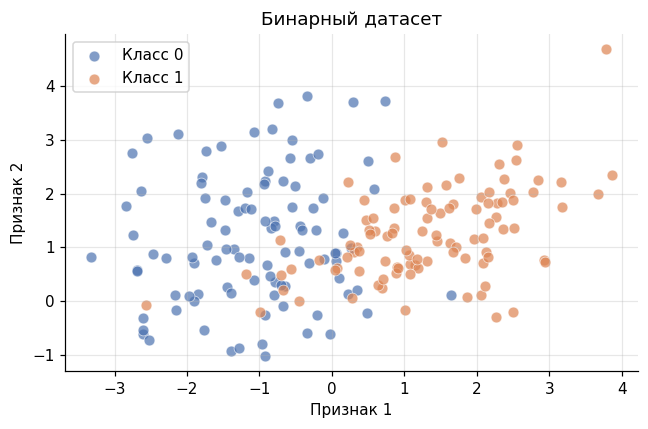

In [ ]:
# Генерируем 2D-датасет для бинарной классификации
X_bin, y_bin = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

def plot_dataset(X, y, title="Датасет", ax=None):
    """Красиво рисуем точки двух классов."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    colors = ["#4C72B0", "#DD8452"]
    for cls, color in zip([0, 1], colors):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=color, label=f"Класс {cls}",
                   alpha=0.7, edgecolors="white", linewidths=0.5, s=50)
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    ax.set_title(title)
    ax.legend()
    return ax

plot_dataset(X_bin, y_bin, title="Бинарный датасет")
plt.tight_layout()
plt.show()


### ❓ Вопрос

Посмотри на график. **Где примерно должна проходить граница между классами?**  
Нарисуй мысленно прямую линию, которая разделяет синие и оранжевые точки.

> *Линейный классификатор — это именно такая прямая (в 2D) или гиперплоскость (в общем случае).*


---
## Раздел 2. Сигмоида

**Сигмоида** — монотонная S-образная функция, которая переводит любое $z \in \mathbb{R}$ в число $p \in (0, 1)$.

### Логистическая сигмоида

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Свойства: монотонно возрастает, $\sigma(0) = 0.5$, при $z \to \pm\infty$ стремится к $1$ и $0$.

---


In [ ]:
def logistic_sigmoid(z):
    """sigma(z) = 1 / (1 + exp(-z))"""
    # ========= TODO =========
    pass
    # ========================

# Проверка
x_test = np.array([-3.0, 0.0, 3.0])
print("logistic_sigmoid([-3, 0, 3]):", logistic_sigmoid(x_test))


logistic_sigmoid([-3, 0, 3]): None


In [ ]:
def plot_sigmoid(fn, x_grid):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(x_grid, fn(x_grid), color="#4C72B0", lw=2)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(0.0, color="gray", linestyle=":",  alpha=0.5)
    ax.set_xlabel("z (score)")
    ax.set_ylabel("\u03c3(z)")
    ax.set_title("Логистическая сигмоида")
    plt.tight_layout()
    plt.show()

x_grid = np.linspace(-6, 6, 300)
plot_sigmoid(logistic_sigmoid, x_grid)


> Почему сигмоиду вообще нельзя убрать и оставить просто $z$ как предсказание вероятности?


---
## Раздел 3. Функции потерь

Пусть $y \in \{0, 1\}$ — истинная метка, $p \in (0, 1)$ — предсказанная вероятность.

### MSE

$$\text{MSE}(p, y) = (p - y)^2, \qquad \frac{\partial \text{MSE}}{\partial p} = 2(p - y)$$

### Binary Cross-Entropy (BCE)

$$\text{BCE}(p, y) = -\bigl(y \log p + (1-y)\log(1-p)\bigr), \qquad \frac{\partial \text{BCE}}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p}$$

> BCE определена только при $p \in (0, 1)$ — на практике берут $p = \text{clip}(p,\, \varepsilon,\, 1-\varepsilon)$.

---


In [ ]:
def mse_loss(p, y):
    # ========= TODO (1/2) =========
    pass
    # ==============================

def bce_loss(p, y, eps=1e-7):
    # ========= TODO (2/2) =========
    pass
    # ==============================

# Проверка
print("p=0.9, y=1 →  MSE:", mse_loss(0.9, 1), "  BCE:", bce_loss(0.9, 1))
print("p=0.1, y=1 →  MSE:", mse_loss(0.1, 1), "  BCE:", bce_loss(0.1, 1))


In [ ]:
def plot_loss_functions(loss_fns, p_grid):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    colors = ["#4C72B0", "#DD8452"]
    for ax, y_val, title in zip(axes, [1, 0], ["y = 1", "y = 0"]):
        for (name, fn), color in zip(loss_fns.items(), colors):
            ax.plot(p_grid, fn(p_grid, y_val), label=name, color=color, lw=2)
        ax.set_xlabel("p")
        ax.set_ylabel("loss")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

p_grid = np.linspace(0.01, 0.99, 300)
plot_loss_functions({"MSE": mse_loss, "BCE": bce_loss}, p_grid)


> Какая функция сильнее штрафует модель за уверенный неправильный ответ? Почему BCE обычно предпочтительнее MSE для задачи классификации?


---
## Раздел 4. Логистическая регрессия руками

$$z = Xw + b \quad\longrightarrow\quad p = \sigma(z) \quad\longrightarrow\quad L(p, y)$$

Градиенты потерь по $w$ и $b$ (с учётом производной сигмоиды $\sigma'(z) = p(1-p)$):

| Потеря | $\partial L / \partial w$ | $\partial L / \partial b$ |
|--------|------|------|
| **BCE** | $\dfrac{1}{n}\, X^\top(p - y)$ | $\dfrac{1}{n}\sum_i (p_i - y_i)$ |
| **MSE** | $\dfrac{2}{n}\, X^\top\!\bigl[(p-y)\cdot p(1-p)\bigr]$ | $\dfrac{2}{n}\sum_i (p_i - y_i)\,p_i(1-p_i)$ |

Шаг градиентного спуска: $w \leftarrow w - \alpha \cdot \partial L/\partial w$, аналогично для $b$.

---


In [ ]:
def linear_score(X, w, b):
    # ========= TODO (1/2) =========
    pass
    # ==============================

def predict_proba(X, w, b):
    # ========= TODO (2/2) =========
    pass
    # ==============================

def compute_loss(y, p, loss_name="bce", eps=1e-7):
    p = np.clip(p, eps, 1 - eps)
    if loss_name == "bce":
        return np.mean(bce_loss(p, y))
    elif loss_name == "mse":
        return np.mean(mse_loss(p, y))
    else:
        raise ValueError(loss_name)

# Проверка
w_test = np.array([1.0, 0.0])
X_test = np.array([[1, 2], [3, 4]])
print("linear_score =", linear_score(X_test, w_test, 0.0))  # ожидаем [1. 3.]
print("predict_proba =", predict_proba(X_test, w_test, 0.0))  # ожидаем [0.73 0.95]


Дополни цикл обучения — заполни 5 пропусков. Формулы градиентов уже в таблице выше.


In [ ]:
def train_logreg(X, y, loss_name="bce", lr=0.1, n_steps=500):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history = []

    for step in range(n_steps):

        # ========= TODO (1/5): вычисли линейный score =========
        z = None
        # ======================================================

        # ========= TODO (2/5): вычисли вероятности =========
        p = None
        # ====================================================

        # ========= TODO (3/5): вычисли потерю =========
        loss = None
        # ==============================================

        # ========= TODO (4/5): вычисли градиенты =========
        if loss_name == "bce":
            grad_w = None
            grad_b = None
        elif loss_name == "mse":
            grad_w = None
            grad_b = None
        # ==================================================

        # ========= TODO (5/5): обнови параметры =========
        # ================================================

        loss_history.append(loss)

    return w, b, loss_history


In [ ]:
def plot_learning_curve(loss_history, title="Кривая обучения"):
    """Рисует loss по шагам обучения."""
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(loss_history, color="#4C72B0", lw=2)
    ax.set_xlabel("Шаг обучения")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(X, y, w, b, title="Граница решения"):
    """Рисует разделяющую границу логистической регрессии на 2D-данных."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = logistic_sigmoid(linear_score(grid, w, b)).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contourf(xx, yy, probs, levels=50, cmap="RdYlBu_r", alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    colors = ["#4C72B0", "#DD8452"]
    for cls, color in zip([0, 1], colors):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=color,
                   label=f"Класс {cls}", edgecolors="white",
                   linewidths=0.5, s=50, alpha=0.9)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Обучаем модель
w_fit, b_fit, loss_hist = train_logreg(X_bin, y_bin, loss_name="bce", lr=0.1, n_steps=300)

print(f"Финальные веса: w = {w_fit}, b = {b_fit:.4f}")
print(f"Финальный loss: {loss_hist[-1]:.4f}")

# Кривая обучения
plot_learning_curve(loss_hist)

# Граница решения
plot_decision_boundary(X_bin, y_bin, w_fit, b_fit)


> Попробуй изменить `lr` и `n_steps` — как это влияет на форму кривой обучения и на границу решения?


---
## Раздел 5. Порог классификации

После обучения модель выдаёт **вероятности** $p \in (0, 1)$.  
Чтобы получить бинарный ответ ($0$ или $1$), нужно выбрать **порог** $t$:

$$\hat{y} = \begin{cases} 1, & p \geq t \\ 0, & p < t \end{cases}$$

Порог $t$ по умолчанию часто берут $t = 0.5$, но это не всегда оптимально.

### Мини-эксперимент: разные пороги


In [ ]:
# Получаем вероятности обученной модели
probs = predict_proba(X_bin, w_fit, b_fit)

# Смотрим на несколько примеров
print("Вероятности первых 10 объектов:")
print(np.round(probs[:10], 3))
print("Истинные метки:                 ")
print(y_bin[:10])


In [ ]:
from sklearn.metrics import precision_recall_curve

def apply_threshold(probs, threshold):
    """Получает бинарные предсказания по вероятностям и порогу."""
    # ========= TODO =========
    pass
    # ========================

thresholds = [0.3, 0.5, 0.7]

print(f"{'Порог':>8} | {'Предсказано 1':>15} | {'Предсказано 0':>15} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10}")
print("-" * 83)
for t in thresholds:
    preds = apply_threshold(probs, t)
    # ========= TODO =========
    accuracy = None
    precision = None
    recall = None
    # ========================
    n1 = preds.sum()
    n0 = len(preds) - n1
    print(f"t = {t:.1f}   | {n1:>15} | {n0:>15} | {accuracy:>9.3f} | {precision:>10.3f} | {recall:>9.3f} | ")


In [ ]:
# --- Сетка для картинки ---
x_min, x_max = X_bin[:, 0].min() - 0.5, X_bin[:, 0].max() + 0.5
y_min, y_max = X_bin[:, 1].min() - 0.5, X_bin[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Вероятности на сетке и на обучающей выборке ---
p_grid = logistic_sigmoid(linear_score(grid, w_fit, b_fit)).reshape(xx.shape)
p_data = logistic_sigmoid(linear_score(X_bin, w_fit, b_fit))

colors = ["#4C72B0", "#DD8452"]


def plot_threshold_metrics(t=0.5):
    y_pred = (p_data >= t).astype(int)

    acc = accuracy_score(y_bin, y_pred)
    prec = precision_score(y_bin, y_pred, zero_division=0)
    rec = recall_score(y_bin, y_pred, zero_division=0)
    f1 = f1_score(y_bin, y_pred, zero_division=0)
    auc = roc_auc_score(y_bin, p_data)   # AUC от порога не зависит

    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- График с границей ---
    ax = axes[0]
    ax.contourf(xx, yy, p_grid, levels=50, cmap="RdYlBu_r", alpha=0.5)
    ax.contour(xx, yy, p_grid, levels=[t], colors="black", linewidths=2)

    for cls, color in zip([0, 1], colors):
        mask = y_bin == cls
        ax.scatter(
            X_bin[mask, 0], X_bin[mask, 1],
            c=color,
            edgecolors="white",
            linewidths=0.5,
            s=40,
            alpha=0.9,
            label=f"Класс {cls}"
        )

    ax.set_title(f"Граница решения при threshold = {t:.2f}")
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()

    # --- Матрица ошибок ---
    ax = axes[1]
    cm = np.array(object=[[tn, fp], [fn, tp]])
    im = ax.imshow(cm, cmap="Blues")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    ax.set_title("Матрица ошибок")

    plt.tight_layout()
    plt.show()

    print(f"threshold = {t:.2f}")
    print(f"Accuracy  = {acc:.3f}")
    print(f"Precision = {prec:.3f}")
    print(f"Recall    = {rec:.3f}")
    print(f"F1-score  = {f1:.3f}")
    print(f"ROC-AUC   = {auc:.3f}  (не зависит от порога)")
    print()
    print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")


interact(
    plot_threshold_metrics,
    t=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, description="threshold")
);

### ❓ Вопросы

1. При каком пороге модель "осторожнее" (реже говорит $\hat{y}=1$)? При каком — "агрессивнее"?
2. Какой порог дал наивысшую accuracy в таблице? Почему $t = 0.5$ не всегда оптимален?
3. Как порог влияет на precision и recall? Почему?

### 📌 Переход к ROC

Разные пороги дают разные компромиссы между типами ошибок.  
**ROC-кривая** — это визуализация всех таких компромиссов сразу.  
Вместо одного числа accuracy мы смотрим на всё множество порогов.


---
## Раздел 6. ROC-кривая и ROC-AUC руками

### Определения

Для фиксированного порога $t$ модель выдаёт предсказания $\hat{y}_i$.  
Определим:

- **TP** (True Positive): $y = 1, \hat{y} = 1$ — верно определили положительный
- **FP** (False Positive): $y = 0, \hat{y} = 1$ — ложная тревога
- **TN** (True Negative): $y = 0, \hat{y} = 0$ — верно определили отрицательный
- **FN** (False Negative): $y = 1, \hat{y} = 0$ — пропустили положительный

**True Positive Rate (TPR, чувствительность):**
$$\text{TPR}(t) = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{\text{число правильно найденных «1»}}{\text{всего «1»}}$$

**False Positive Rate (FPR):**
$$\text{FPR}(t) = \frac{\text{FP}}{\text{FP} + \text{TN}} = \frac{\text{число ложно положительных}}{\text{всего «0»}}$$

**ROC-кривая** строится как набор точек $(\text{FPR}(t), \text{TPR}(t))$ для всех порогов $t$.

**ROC-AUC** — площадь под этой кривой, число от 0 до 1 (лучше — ближе к 1).

---

### 🔧 TODO: реализуй ROC-кривую вручную


In [ ]:
def roc_curve_manual(y_true, y_score):
    """
    Строит ROC-кривую вручную.
    Возвращает массивы fpr, tpr, thresholds.
    """
    # Берём все уникальные значения score как пороги
    thresholds = np.sort(np.unique(y_score))[::-1]  # от большого к малому

    fpr_list = []
    tpr_list = []

    P = np.sum(y_true == 1)  # всего положительных
    N = np.sum(y_true == 0)  # всего отрицательных

    for t in thresholds:
        # ========= TODO =========
        y_pred = None
        TP = None
        FP = None
        tpr = None
        fpr = None
        fpr_list.append(fpr)
        tpr_list.append(tpr)
        # ========================

    # Добавляем крайние точки (0,0) и (1,1)
    fpr_arr = np.array([0.0] + fpr_list + [1.0])
    tpr_arr = np.array([0.0] + tpr_list + [1.0])

    return fpr_arr, tpr_arr, thresholds


In [ ]:
def auc_trapezoid(fpr, tpr):
    """Площадь под ROC-кривой методом трапеций."""
    # ========= TODO =========
    pass
    # ========================


In [ ]:
# Вычисляем ROC-кривую
fpr_manual, tpr_manual, thresh_manual = roc_curve_manual(y_bin, probs)
auc_manual = auc_trapezoid(fpr_manual, tpr_manual)

print(f"ROC-AUC (наша реализация): {auc_manual:.4f}")

# Проверяем через sklearn
auc_sklearn = roc_auc_score(y_bin, probs)
print(f"ROC-AUC (sklearn):          {auc_sklearn:.4f}")


In [ ]:
def plot_roc_curve(fpr, tpr, auc_val, label="Наша модель"):
    """Рисует ROC-кривую."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="#4C72B0", lw=2,
            label=f"{label} (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Случайный классификатор")
    ax.fill_between(fpr, tpr, alpha=0.15, color="#4C72B0")
    ax.set_xlabel("FPR (False Positive Rate)")
    ax.set_ylabel("TPR (True Positive Rate)")
    ax.set_title("ROC-кривая")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

plot_roc_curve(fpr_manual, tpr_manual, auc_manual)


### ❓ Вопросы

1. **Что означает диагональная пунктирная линия** на ROC-графике?  
   Какие два разных классификатора ей соответствуют?

2. **Почему ROC-AUC можно считать метрикой качества ранжирования**, а не просто классификации?

> 💡 **Вывод:** ROC-кривая показывает, как меняется компромисс между TPR и FPR при разных порогах. ROC-AUC — это одна метрика, которая суммирует качество ранжирования по всем порогам сразу.


---
## Раздел 7. ROC-AUC как вероятность правильной сортировки пары

### Гипотеза

> **ROC-AUC** равен вероятности того, что случайно выбранный **положительный** объект имеет **больший score**, чем случайно выбранный **отрицательный** объект.

Формально:

$$\text{AUC} = P(\text{score}^+ > \text{score}^-)$$

где $\text{score}^+$ — score для объекта класса 1, $\text{score}^-$ — score для класса 0.

При равенстве scores договариваемся считать $0.5$ (оба исхода равновероятны).

### 🔧 TODO: реализуй попарную оценку AUC


In [ ]:
def pairwise_auc_probability(y_true, y_score):
    """
    Оценивает ROC-AUC как вероятность того,
    что случайный положительный объект имеет больший score,
    чем случайный отрицательный.
    """
    pos_scores = y_score[y_true == 1]  # scores положительных объектов
    neg_scores = y_score[y_true == 0]  # scores отрицательных объектов

    total = 0.0
    count = 0

    for sp in pos_scores:
        for sn in neg_scores:
            # ========= TODO =========
            pass
            # ========================
            count += 1

    return total / count if count > 0 else 0.0

# Вычисляем
auc_pairwise = pairwise_auc_probability(y_bin, probs)

print(f"ROC-AUC (попарный подсчёт): {auc_pairwise:.4f}")
print(f"ROC-AUC (трапеции):         {auc_manual:.4f}")
print(f"ROC-AUC (sklearn):          {auc_sklearn:.4f}")


### ❓ Вопросы

1. **Совпадают ли** три числа в строках выше? Что это означает?

2. **Почему здесь используются score** $p \in (0, 1)$, а не бинарные предсказания $\hat{y} \in \{0, 1\}$?  
   Что изменилось бы, если бы мы брали $\hat{y}$?

3. **Что означает равенство scores** у положительного и отрицательного объекта?  
   Почему мы добавляем $0.5$ в этом случае?

> 💡 **Вывод:** ROC-AUC — это в точности вероятность правильного упорядочивания случайной пары (положительный, отрицательный). Поэтому это метрика **ранжирования**, а не просто классификации.


---
## Раздел 8. Precision@k и Recall@k

### Идея

Представь, что ты сортируешь все объекты по убыванию score и берёшь **top-k** — самые "уверенно положительные".

**Precision@k** — какая доля из top-k объектов действительно положительные:

$$\text{precision@k} = \frac{\text{число положительных в top-k}}{k}$$

**Recall@k** — какую долю от всех положительных мы "поймали" в top-k:

$$\text{recall@k} = \frac{\text{число положительных в top-k}}{\text{всего положительных}}$$

> Эти метрики важны, когда нас интересует **качество топа** (например, поиск, рекомендации, медицинская диагностика).

---

### 🔧 TODO: реализуй precision@k и recall@k


In [ ]:
def precision_at_k(y_true, y_score, k):
    """Precision в топ-k объектах по убыванию score."""
    # ========= TODO =========
    pass
    # ========================

def recall_at_k(y_true, y_score, k):
    """Recall в топ-k объектах по убыванию score."""
    # ========= TODO =========
    pass
    # ========================

# Проверка при k = всё = идеальный recall=1
n_total = len(y_bin)
n_pos = y_bin.sum()
print(f"Всего объектов: {n_total}, из них положительных: {n_pos}")
print(f"precision@{n_total} = {precision_at_k(y_bin, probs, n_total):.3f}  (ожидаем: {n_pos/n_total:.3f})")
print(f"recall@{n_total}    = {recall_at_k(y_bin, probs, n_total):.3f}  (ожидаем: 1.000)")


In [ ]:
# Считаем метрики для разных k
k_values = list(range(1, len(y_bin) + 1, 2))

prec_k = [precision_at_k(y_bin, probs, k) for k in k_values]
rec_k  = [recall_at_k(y_bin, probs, k)    for k in k_values]

# Таблица для нескольких значений k
print(f"{'k':>6} | {'Precision@k':>12} | {'Recall@k':>10}")
print("-" * 35)
for k in [5, 10, 20, 30, 50, 100]:
    p = precision_at_k(y_bin, probs, k)
    r = recall_at_k(y_bin, probs, k)
    print(f"{k:>6} | {p:>12.3f} | {r:>10.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, prec_k, color="#4C72B0", lw=2)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Precision@k")
axes[0].set_title("Precision@k")

axes[1].plot(k_values, rec_k, color="#DD8452", lw=2)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Recall@k")
axes[1].set_title("Recall@k")

plt.tight_layout()
plt.show()


### ❓ Обсуждение

1. Что происходит с **Precision@k** при увеличении $k$? Почему?
2. Что происходит с **Recall@k** при увеличении $k$?
3. **Когда важна "чистота топа"** (precision@k)?  
   Пример: поисковая выдача, рекомендации фильмов.
4. **Когда важнее "поймать как можно больше"** (recall@k)?  
   Пример: медицинский скрининг, обнаружение мошенничества.
5. **Чем эти метрики отличаются от ROC-AUC?**  
   ROC-AUC смотрит на все объекты сразу, а precision/recall@k — только на топ.

> 💡 **Вывод:** precision@k и recall@k — это метрики "топа". Они важны, когда у нас ограниченный бюджет внимания (мы можем проверить только $k$ объектов). ROC-AUC смотрит на всё ранжирование целиком.


---
## Раздел 9. Многоклассовая классификация: One-vs-All

### Постановка

Пусть теперь $y \in \{0, 1, 2, \ldots, C-1\}$ — $C$ классов.  
Бинарная логистическая регрессия умеет работать только с двумя классами. Как расширить её на $C$?

### Стратегия: One-vs-All (OvA)

Для каждого класса $c$ обучаем **отдельную бинарную модель**:

$$\text{модель}_c: \text{ является ли объект классом } c \text{ (1) или нет (0)?}$$

Метки для обучения модели $c$:
$$y_i^{(c)} = \begin{cases} 1, & y_i = c \\ 0, & y_i \neq c \end{cases}$$

На предсказании для нового объекта $x$:
1. Вычисляем вероятности $p_c = \sigma_c(x)$ от каждой из $C$ моделей.
2. Предсказываем класс с максимальной вероятностью: $\hat{y} = \arg\max_c \, p_c$.

### Синтетический датасет с 3 классами


In [ ]:
X_multi, y_multi = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3,
    cluster_std=4.0,
    random_state=42
)

def plot_dataset_multi(X, y, title="Многоклассовый датасет", ax=None):
    """Рисует точки нескольких классов."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    classes = np.unique(y)
    for cls in classes:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette[cls], label=f"Класс {cls}",
                   alpha=0.7, edgecolors="white", linewidths=0.5, s=50)
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    ax.set_title(title)
    ax.legend()
    return ax

plot_dataset_multi(X_multi, y_multi)
plt.tight_layout()
plt.show()

n_classes = len(np.unique(y_multi))
print(f"Классов: {n_classes}, объектов: {len(y_multi)}")


### 🔧 TODO: реализуй One-vs-All классификацию


In [ ]:
def train_ova(X, y, lr=0.1, n_steps=500):
    """One-vs-All: для каждого класса — своя бинарная модель."""
    classes = np.unique(y)
    models = []

    for c in classes:
        # ========= TODO (1/3): сформируй бинарные метки для класса c =========
        y_bin_c = None
        # ======================================================================

        # ========= TODO (2/3): обучи бинарную логрег =========
        # =====================================================

        # ========= TODO (3/3): добавь (w_c, b_c) в models =========
        # ===========================================================

    return models

def predict_ova(X, models):
    """Предсказание: argmax вероятностей по всем классам."""
    # ========= TODO =========
    all_probs = []
    for (w_c, b_c) in models:
        p_c = None # TODO
        all_probs.append(p_c)
    P = np.column_stack(all_probs)
    return np.argmax(P, axis=1)
    # ========================


In [ ]:
# Обучаем OvA
ova_models = train_ova(X_multi, y_multi, lr=0.1, n_steps=500)

# Предсказания
y_pred_ova = predict_ova(X_multi, ova_models)

# Точность
accuracy = np.mean(y_pred_ova == y_multi)
print(f"Accuracy на обучающей выборке: {accuracy:.3f}")


In [ ]:
def plot_decision_regions_ova(X, y, models, title="One-vs-All"):
    """Рисует цветные области решения для OvA."""
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    preds = predict_ova(grid, models).reshape(xx.shape)

    palette_bg = ["#AEC6E8", "#F5C89A", "#A8D8B0", "#F0A0A0"]
    palette_fg = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    cmap_bg = ListedColormap(palette_bg[:len(models)])
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, preds, cmap=cmap_bg, alpha=0.7)

    classes = np.unique(y)
    for cls in classes:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette_fg[cls], label=f"Класс {cls}",
                   edgecolors="white", linewidths=0.5, s=50, alpha=0.9)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_decision_regions_ova(X_multi, y_multi, ova_models)


### Плюсы и минусы One-vs-All

| Плюсы | Минусы |
|-------|--------|
| Просто реализовать | Классы могут быть несбалансированы |
| Работает с любым бинарным классификатором | Модели обучаются независимо — не знают друг о друге |
| Хорошо масштабируется (C моделей) | Вероятности с разных моделей не нормированы |

---

## One-vs-One (OvO)


### Идея

Вместо "один против всех" обучаем **одну модель на каждую пару классов** $(c_i, c_j)$.  
Всего таких пар: $\binom{C}{2} = \frac{C(C-1)}{2}$.

На предсказании каждая модель "голосует" за один из двух классов.  
Выбирается класс, набравший больше всего голосов.

### 🔧 TODO : реализуй One-vs-One


In [ ]:
from itertools import combinations

def train_ovo(X, y, lr=0.1, n_steps=500):
    """OvO: модель для каждой пары классов. Возвращает {(i,j): (w,b)}."""
    classes = np.unique(y)
    ovo_models = {}

    for c_i, c_j in combinations(classes, 2):
        mask = (y == c_i) | (y == c_j)
        X_pair = X[mask]
        y_pair = (y[mask] == c_i).astype(int)
        # ========== TODO ==========
        # обучи модель и сохрани в ovo_models[(c_i, c_j)]
        pass
        # ==========================

    return ovo_models

def predict_ovo(X, ovo_models, classes):
    n = len(X)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    votes = np.zeros((n, len(classes)))

    for (c_i, c_j), (w, b) in ovo_models.items():
        p = predict_proba(X, w, b)
        # ========== TODO ==========
        # если p >= 0.5 → голос за c_i, иначе → голос за c_j
        pass
        # ==========================


    return classes[np.argmax(votes, axis=1)]

ovo_models = train_ovo(X_multi, y_multi)
y_pred_ovo = predict_ovo(X_multi, ovo_models, np.unique(y_multi))
print(f"OvO Accuracy: {np.mean(y_pred_ovo == y_multi):.3f}")



Визуализируем границы решения для OvO и сравниваем с OvA.

In [ ]:
def plot_decision_regions_ovo(X, y, ovo_models, title="One-vs-One"):
    """Рисует цветные области решения для OvO."""
    classes = np.unique(y)
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    preds = predict_ovo(grid, ovo_models, classes).reshape(xx.shape)

    palette_bg = ["#AEC6E8", "#F5C89A", "#A8D8B0", "#F0A0A0"]
    palette_fg = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    cmap_bg = ListedColormap(palette_bg[:len(classes)])
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, preds, cmap=cmap_bg, alpha=0.7)

    for cls in classes:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette_fg[cls], label=f"Класс {cls}",
                   edgecolors="white", linewidths=0.5, s=50, alpha=0.9)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_decision_regions_ovo(X_multi, y_multi, ovo_models)


### ❓ Вопросы

1. **Почему OvA может работать плохо** при сильном дисбалансе классов?  
   Например, если 90% объектов — класс 0, 5% — класс 1, 5% — класс 2?

2. **Сравни OvA и OvO:** в чём принципиальная разница стратегий?

3. **Чем хуже** простое применение `argmax` к вероятностям OvA, чем softmax-регрессия?

> 💡 **Вывод:** OvA — простой и эффективный способ расширить бинарный классификатор на несколько классов. Каждая модель решает свою подзадачу независимо.


## Мультиклассовая логистическая регрессия

Давайте реализуем её руками, без sklearn. Для этого у вас знания с лекции и код из предыдущих разделов.
Единственное, вам может быть полезен аналитический градиент для многоклассовой логистической регрессии. Если использовать softmax в качестве функции активации и кросс-энтропию в качестве функции потерь, то градиент по весам $W$ иbias $b$ будут выглядеть так:

$$\frac{\partial L}{\partial W} = \frac{1}{n} X^\top (P - Y)$$
$$\frac{\partial L}{\partial b} = \frac{1}{n} \mathbf{1}^\top (P - Y)$$
где $P$ — матрица предсказанных вероятностей для каждого класса, $Y$ — one-hot кодировка истинных меток, a $\mathbf{1}$ — вектор единиц.

In [ ]:
# ========== TODO ==========
# Проверните целиком pipeline обучения и предсказания для мультиклассовой логистической регрессии, посчитайте точность и нарисуйте границы решения.
# ==========================

Сравните метрики (не только accuracy) для этих трех моделей. Какая из них лучше? Почему?

---
## Раздел 10. Итоги

Поздравляем с завершением! Ты реализовал логистическую регрессию, три функции потерь, ROC-кривую, две метрики ранжирования и многоклассовый классификатор — всё руками, без магии sklearn. 🎉
